In [3]:
import pandas as pd
from pysyncon import Dataprep, Synth
from pysyncon.utils import PlaceboTest
import numpy as np
from statsmodels.formula.api import ols

In [4]:
#Загрузка данных
df = pd.read_excel( "C:\\Users\\mtaip\\Downloads\\Investment data.xlsx ")
df.head()

,year,CAPEX,Industry
0,2000,31.0991,Network
1,2001,45.0827,Network
2,2002,59.8975,Network
3,2003,104.6227,Network
4,2004,155.6929,Network


In [6]:
dataprep = Dataprep(
    foo=df,
    predictors=["CAPEX"],
    predictors_op="mean",
    time_predictors_prior=range(2000,2016),
   
    dependent="CAPEX",
    unit_variable="Industry",
    time_variable="year",
    treatment_identifier="Network",
    controls_identifier=[
         "Food", "retail","metallurgy","healthcare","real estate","agriculture","finance","paper","building","mining","science","water transport",
"education","water purification","land transport","aviation"
    ],
    time_optimize_ssr=range(2000, 2016),
)
print(dataprep)

Dataprep
Treated unit: Network
Dependent variable: CAPEX
Control units: Food, retail, metallurgy, healthcare, real estate, agriculture, finance, paper, building, mining, science, water transport, education, water purification, land transport, aviation
Time range in data: 2000 - 2023
Time range for loss minimization: range(2000, 2016)
Time range for predictors: range(2000, 2016)
Predictors: CAPEX



In [7]:

synth = Synth()
#Настройка синтетического контроля
synth.fit(dataprep=dataprep, optim_method="BFGS", optim_initial="ols")
#Полученные веса
synth.weights(threshold=0.01)

Food                  0.065
retail                0.040
metallurgy            0.057
healthcare            0.065
real estate           0.040
agriculture           0.040
finance               0.075
paper                 0.091
building              0.040
mining                0.040
science               0.084
water transport       0.093
education             0.068
water purification    0.086
land transport        0.040
aviation              0.078
Name: weights, dtype: float64

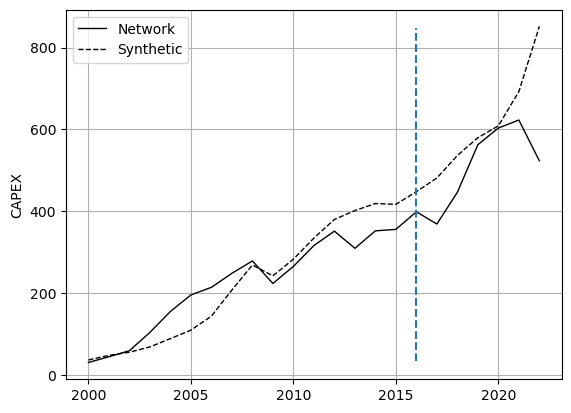

In [8]:
#Графики инвестиций в отрасль связи и синтетического контроля
synth.path_plot(time_period=range(2000, 2023), treatment_time=2016)

In [9]:
#плацебо-тест
placebo_test = PlaceboTest()
placebo_test.fit(
    dataprep=dataprep,
    scm=synth,
    scm_options={"optim_method":"BFGS", "optim_initial":"ols"   },
)

(1/16) Completed placebo test for finance.
(2/16) Completed placebo test for education.
(3/16) Completed placebo test for healthcare.
(4/16) Completed placebo test for metallurgy.
(5/16) Completed placebo test for retail.
(6/16) Completed placebo test for Food.
(7/16) Completed placebo test for water purification.
(8/16) Completed placebo test for land transport.
(9/16) Completed placebo test for agriculture.
(10/16) Completed placebo test for water transport.
(11/16) Completed placebo test for aviation.
(12/16) Completed placebo test for mining.
(13/16) Completed placebo test for real estate.
(14/16) Completed placebo test for science.
(15/16) Completed placebo test for building.
(16/16) Completed placebo test for paper.
Calculating treated unit gaps.
Done.


In [10]:
#Тест Фишера на отсутствие эффекта сетевого нейтралитета
placebo_test.pvalue(treatment_time=2016)

0.35294117647058826